# Foods & Goods

Análise de logística: distância e custo das entregas de moto por estado

**Pergunta:** como a distância das entregas de moto varia entre os estados atendidos?

**Contexto:** a equipe responsável pelos preços quer entender essas diferenças antes de discutir a remuneração das entregas. Nossa análise vai fornecer essa comparação; não precisamos definir um preço agora.

**Complemento:** comparar o custo de entrega registrado por quilômetro. Esse campo não comprova remuneração paga ao entregador.

Fonte: [Delivery Center — Foods & Goods, Kaggle](https://www.kaggle.com/datasets/nosbielcs/brazilian-delivery-center). Pedidos de janeiro a abril de 2021. Estado do **hub de origem**, não do cliente. Distância registrada na base, não quilometragem total de trabalho do entregador.

### O caminho do projeto

Começamos com um panorama geral da operação: pedidos concluídos por dia e mês, variação mensal (MoM), valor bruto movimentado (GMV) e ticket médio (AOV). Essa primeira etapa ajudou a conhecer a base e levantar perguntas, sem atribuir causas às diferenças observadas.

Em seguida, simulamos uma demanda da equipe de preços: entender como as distâncias das entregas de moto variam entre os estados antes de discutir remuneração. Transformamos esse contexto em uma pergunta de negócio e construímos a consulta SQL passo a passo no DBeaver, relacionando entregas, pedidos, lojas, hubs e motoristas.

Por fim, levamos os resultados ao Python no VS Code para visualizar as diferenças. Acrescentamos o custo registrado por km como complemento à comparação e verificamos limitações da base. O resultado é uma análise descritiva para apoiar a discussão, sem definir preços ou afirmar quanto cada entregador recebeu.


## 1. Carregar as ferramentas
`pandas` recebe os dados em uma tabela chamada DataFrame; `matplotlib` será usado para o gráfico; `sqlalchemy` conecta ao PostgreSQL usando o driver psycopg.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text, URL
from getpass import getpass
import os

print('Bibliotecas carregadas. Pronto para conectar.')

Bibliotecas carregadas. Pronto para conectar.


## 2. Conectar ao banco
Digite a senha do PostgreSQL quando o VS Code solicitar. Ela não aparece no código nem é salva no notebook. O banco é o mesmo acessado pelo DBeaver.

Esta configuração permite consultas somente de leitura.

In [ ]:
if 'engine' in globals():
    engine.dispose()

engine = create_engine(
    URL.create(
        'postgresql+psycopg',
        username=os.getenv('PGUSER', 'postgres'),
        password=getpass('Senha do PostgreSQL: '),
        host=os.getenv('PGHOST', 'localhost'),
        port=int(os.getenv('PGPORT', '5432')),
        database=os.getenv('PGDATABASE', 'postgres'),
    ),
    connect_args={
        'connect_timeout': 5,
        'options': '-c default_transaction_read_only=on -c statement_timeout=30000',
    },
)

with engine.connect() as conexao:
    verificacao = pd.read_sql_query(text('''
        select
            current_database() as banco,
            current_user as usuario,
            current_setting('transaction_read_only') as somente_leitura,
            min(order_moment_created)::date as inicio_dos_pedidos,
            max(order_moment_created)::date as fim_dos_pedidos
        from "Foods and Goods".orders
    '''), conexao)

verificacao

## 3. Guardar nossa consulta SQL
As três aspas permitem escrever um texto com várias linhas. Guardar esse texto ainda não executa a consulta.

Mantemos a quantidade como número, sem `to_char` ou `replace`, para usá-la em análises.

In [11]:
consulta = '''
select
    h.hub_state as estado,
    count(d.delivery_distance_meters) as entregas_com_distancia,
    round((avg(d.delivery_distance_meters) / 1000.0)::numeric, 2) as distancia_media_km
from "Foods and Goods".deliveries as d
join "Foods and Goods".orders as o
    on d.delivery_order_id = o.order_id
join "Foods and Goods".stores as s
    on o.store_id = s.store_id
join "Foods and Goods".hubs as h
    on s.hub_id = h.hub_id
join "Foods and Goods".drivers as dr
    on d.driver_id = dr.driver_id
where d.delivery_status = 'DELIVERED'
  and dr.driver_modal = 'MOTOBOY'
group by h.hub_state
order by distancia_media_km desc;
'''


## 4. Executar o SQL e receber a tabela
`pd.read_sql_query` envia a consulta ao banco e devolve um DataFrame. Vamos chamá-lo de `df`. Ao deixar `df` na última linha, o notebook exibe a tabela.

In [12]:
with engine.connect() as conexao:
    df = pd.read_sql_query(text(consulta), conexao)

df

,estado,entregas_com_distancia,distancia_media_km
0,RS,29014,3.77
1,SP,126792,3.61
2,PR,24504,3.31
3,RJ,84959,3.13


## 5. Distância média por estado

Entregas `DELIVERED`, modal `MOTOBOY`. A média ignora distâncias nulas e mantém os demais valores, reproduzindo nossa consulta original. Os rótulos informam quantas entregas têm distância preenchida. Não há remoção automática de extremos.

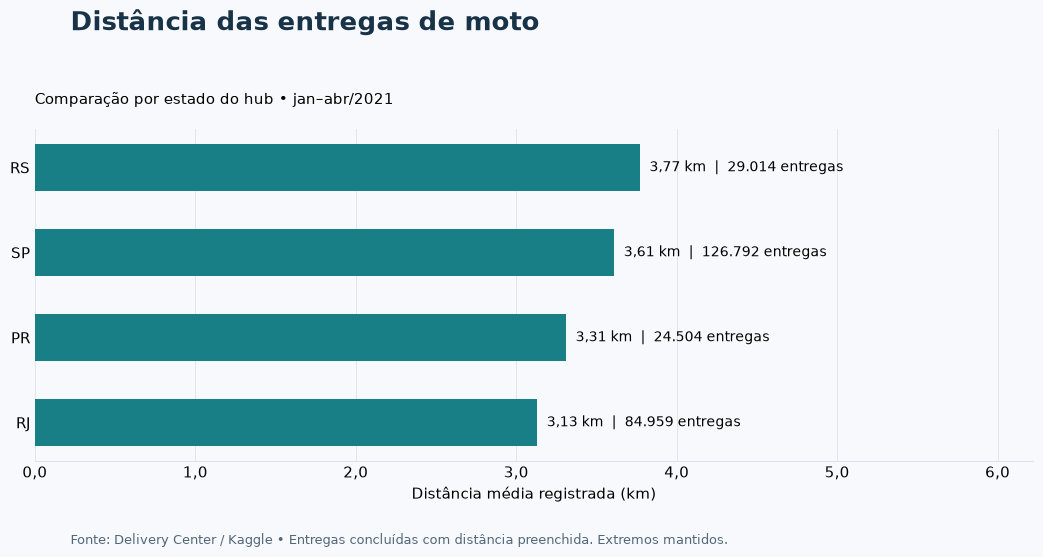

In [13]:
from pathlib import Path
from matplotlib.ticker import FuncFormatter

pasta_saida = Path.cwd() / 'graficos'
pasta_saida.mkdir(exist_ok=True)

def numero_br(valor, casas=2):
    return f'{valor:,.{casas}f}'.replace(',', '_').replace('.', ',').replace('_', '.')

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.titleweight': 'bold', 'axes.edgecolor': '#dbe3ea'})

dados = df.sort_values('distancia_media_km', ascending=False)
fig, ax = plt.subplots(figsize=(11, 5.6))
fig.patch.set_facecolor('#f7f9fc')
ax.set_facecolor('#f7f9fc')
barras = ax.barh(dados['estado'], dados['distancia_media_km'], color='#197f86', height=0.55)
ax.invert_yaxis()
for barra, media, quantidade in zip(barras, dados['distancia_media_km'], dados['entregas_com_distancia']):
    ax.text(media + 0.06, barra.get_y() + barra.get_height()/2,
            f'{numero_br(media)} km  |  {numero_br(quantidade, 0)} entregas', va='center', fontsize=10)
ax.set_xlim(0, dados['distancia_media_km'].max() * 1.65)
ax.set_xlabel('Distância média registrada (km)')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: numero_br(x, 1)))
ax.set_axisbelow(True)
ax.grid(axis='x', color='#dfe6ed', linewidth=0.7)
ax.tick_params(axis='both', length=0)
for lado in ['top', 'right', 'left']:
    ax.spines[lado].set_visible(False)
fig.suptitle('Distância das entregas de moto', x=0.09, ha='left', fontsize=19, fontweight='bold', color='#183247')
ax.set_title('Comparação por estado do hub • jan–abr/2021', loc='left', fontsize=11, fontweight='normal', pad=18)
fig.text(0.09, 0.025, 'Fonte: Delivery Center / Kaggle • Entregas concluídas com distância preenchida. Extremos mantidos.', fontsize=9, color='#536779')
fig.tight_layout(rect=[0.02, 0.07, 0.98, 0.94])
fig.savefig(pasta_saida / '01_distancia_media_por_estado.png', dpi=180, facecolor=fig.get_facecolor())
plt.show()


## 6. Custo registrado por km — definição e consulta SQL

**Indicador = soma dos custos dos pedidos elegíveis ÷ soma das distâncias das entregas desses mesmos pedidos.** É uma razão de totais, não a média simples das razões individuais.

- Campo utilizado: `orders.order_delivery_cost`. Usamos a denominação **custo registrado**, sem assumir repasse ao motoboy. `order_delivery_fee` e pagamentos do pedido não representam esse repasse.
- A distância é somada por pedido antes do join ao custo. Assim, pedidos com várias entregas não repetem seu custo. Isso soma registros de entrega, sem comprovar que sejam trechos únicos de uma rota.
- Só entram pedidos cujas entregas concluídas sejam todas de moto. Modal ausente ou misto fica fora deste indicador.
- Todos os registros de distância do pedido precisam ser preenchidos e positivos. Custo nulo ou negativo exclui o pedido; custo zero é mantido e mostrado separadamente.
- Numerador e denominador usam exatamente os mesmos pedidos. A cobertura mostra a proporção elegível entre os pedidos somente de moto ligados a loja e hub.
- A amostra de custo é mais restrita que a do gráfico de distância. Não compare seus totais como se fossem a mesma amostra.

**Não é uma tabela de preço nem comprovação de pagamento por km.** Para medir remuneração efetiva, precisaríamos de dados de repasses aos entregadores e sua associação às entregas.


In [14]:
consulta_custo = '''
with entregas_por_pedido as (
    -- Agrega antes de juntar ao custo: cada pedido contribuirá uma única vez.
    select
        d.delivery_order_id,
        count(*) as quantidade_entregas,
        sum(d.delivery_distance_meters) / 1000.0 as distancia_pedido_km,
        bool_and(coalesce(dr.driver_modal = 'MOTOBOY', false)) as somente_moto,
        bool_and(coalesce(d.delivery_distance_meters > 0, false)) as distancias_validas
    from "Foods and Goods".deliveries as d
    left join "Foods and Goods".drivers as dr
        on d.driver_id = dr.driver_id
    where d.delivery_status = 'DELIVERED'
    group by d.delivery_order_id
), base as (
    select
        h.hub_state as estado,
        e.*,
        o.order_delivery_cost as custo_pedido,
        e.distancias_validas
            and o.order_delivery_cost is not null
            and o.order_delivery_cost >= 0 as elegivel
    from entregas_por_pedido as e
    join "Foods and Goods".orders as o
        on e.delivery_order_id = o.order_id
    join "Foods and Goods".stores as s
        on o.store_id = s.store_id
    join "Foods and Goods".hubs as h
        on s.hub_id = h.hub_id
    where e.somente_moto
)
select
    estado,
    count(*) as pedidos_somente_moto,
    count(*) filter (where elegivel) as pedidos_com_custo_e_distancia,
    count(*) filter (where not elegivel) as pedidos_excluidos,
    round(100.0 * count(*) filter (where elegivel) / nullif(count(*), 0), 2) as cobertura_pct,
    count(*) filter (where elegivel and custo_pedido = 0) as pedidos_custo_zero,
    count(*) filter (where elegivel and quantidade_entregas > 1) as pedidos_multiplas_entregas,
    round((sum(custo_pedido) filter (where elegivel))::numeric, 2) as custo_total_registrado,
    round((sum(distancia_pedido_km) filter (where elegivel))::numeric, 2) as distancia_total_km,
    round(((sum(custo_pedido) filter (where elegivel)) /
        nullif(sum(distancia_pedido_km) filter (where elegivel), 0))::numeric, 2) as custo_registrado_por_km,
    round((max(distancia_pedido_km) filter (where elegivel))::numeric, 2) as maior_distancia_pedido_km
from base
group by estado
order by custo_registrado_por_km desc;
'''

with engine.connect() as conexao:
    df_custo = pd.read_sql_query(text(consulta_custo), conexao)

df_custo

,estado,pedidos_somente_moto,pedidos_com_custo_e_distancia,pedidos_excluidos,cobertura_pct,pedidos_custo_zero,pedidos_multiplas_entregas,custo_total_registrado,distancia_total_km,custo_registrado_por_km,maior_distancia_pedido_km
0,RJ,76584,75915,669,99.13,1062,6142,661094.90,254006.65,2.60,7019.37
1,PR,22620,22291,329,98.55,126,1383,179458.44,78540.78,2.28,1066.18
2,SP,120176,119209,967,99.20,1192,4923,974544.39,440677.72,2.21,1283.09
3,RS,28040,27995,45,99.84,326,821,232637.26,109050.60,2.13,7251.29


## 7. Quadro comparativo

A distância média e sua contagem vêm da consulta original. O custo/km e a cobertura vêm da amostra elegível descrita acima. Os valores continuam numéricos; a formatação é apenas visual.

In [ ]:
comparativo = df.merge(df_custo, on='estado', how='left', validate='one_to_one')
colunas = ['estado', 'entregas_com_distancia', 'distancia_media_km',
           'custo_registrado_por_km', 'pedidos_com_custo_e_distancia', 'cobertura_pct']
rotulos = {'estado': 'Estado do hub', 'entregas_com_distancia': 'Entregas com distância',
           'distancia_media_km': 'Distância média (km)',
           'custo_registrado_por_km': 'Custo registrado (R$/km)',
           'pedidos_com_custo_e_distancia': 'Pedidos elegíveis para custo',
           'cobertura_pct': 'Cobertura do custo (%)'}
(comparativo[colunas].rename(columns=rotulos).style
 .format({'Entregas com distância': '{:,.0f}', 'Distância média (km)': '{:.2f}',
          'Custo registrado (R$/km)': '{:.2f}', 'Pedidos elegíveis para custo': '{:,.0f}',
          'Cobertura do custo (%)': '{:.2f}'}, decimal=',', thousands='.', na_rep='—')
 .hide(axis='index')
 .set_caption('Entregas de moto | janeiro a abril de 2021')
 .set_table_styles([{'selector': 'th', 'props': [('background-color', '#183247'), ('color', 'white'), ('padding', '12px')]},
                    {'selector': 'td', 'props': [('padding', '12px'), ('border-bottom', '1px solid #dfe6ed')]},
                    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding', '12px')]}]))

Estado do hub,Entregas com distância,Distância média (km),Custo registrado (R$/km),Pedidos elegíveis para custo,Cobertura do custo (%)
RS,29.014,"3,77","2,13",27.995,"99,84"
SP,126.792,"3,61","2,21",119.209,"99,20"
PR,24.504,"3,31","2,28",22.291,"98,55"
RJ,84.959,"3,13","2,60",75.915,"99,13"


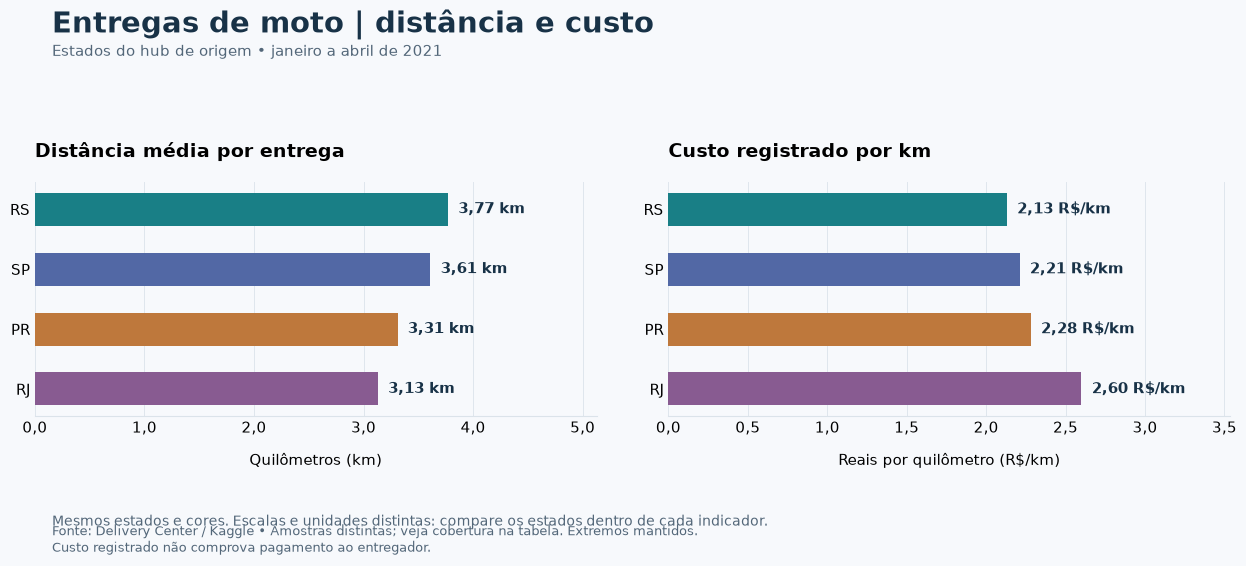

In [ ]:
# Mesma ordem e mesmas cores: cada linha representa o mesmo estado nos dois painéis.
dados_painel = comparativo.sort_values('distancia_media_km', ascending=False).reset_index(drop=True)
cores = ['#197f86', '#5268a5', '#be783c', '#885b91']
fig, eixos = plt.subplots(1, 2, figsize=(13, 5.8))
fig.patch.set_facecolor('#f7f9fc')

configuracoes = [
    ('distancia_media_km', 'Distância média por entrega', 'Quilômetros (km)', ' km'),
    ('custo_registrado_por_km', 'Custo registrado por km', 'Reais por quilômetro (R$/km)', ' R$/km'),
]
for ax, (coluna, titulo, unidade, sufixo) in zip(eixos, configuracoes):
    valores = dados_painel[coluna]
    ax.set_facecolor('#f7f9fc')
    barras = ax.barh(dados_painel['estado'], valores, color=cores, height=0.55)
    ax.invert_yaxis()
    ax.set_xlim(0, valores.max() * 1.36)
    for barra, valor in zip(barras, valores):
        ax.text(valor + valores.max() * 0.025, barra.get_y() + barra.get_height()/2,
                numero_br(valor) + sufixo, va='center', fontsize=11, fontweight='bold', color='#183247')
    ax.set_title(titulo, loc='left', fontsize=14, pad=18)
    ax.set_xlabel(unidade, labelpad=12)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: numero_br(x, 1)))
    ax.set_axisbelow(True)
    ax.grid(axis='x', color='#dfe6ed', linewidth=0.7)
    ax.tick_params(axis='both', length=0)
    for lado in ['top', 'right', 'left']:
        ax.spines[lado].set_visible(False)

fig.suptitle('Entregas de moto | distância e custo', x=0.065, y=0.98,
             ha='left', fontsize=21, fontweight='bold', color='#183247')
fig.text(0.065, 0.90, 'Estados do hub de origem • janeiro a abril de 2021', fontsize=11, color='#536779')
fig.text(0.065, 0.09, 'Mesmos estados e cores. Escalas e unidades distintas: compare os estados dentro de cada indicador.', fontsize=10, color='#536779')
fig.text(0.065, 0.045, 'Fonte: Delivery Center / Kaggle • Amostras distintas; veja cobertura na tabela. Extremos mantidos.\nCusto registrado não comprova pagamento ao entregador.', fontsize=9, color='#536779')
fig.tight_layout(rect=[0.02, 0.16, 0.99, 0.86], w_pad=3)
fig.savefig(pasta_saida / '03_comparacao_distancia_e_custo.png', dpi=180, facecolor=fig.get_facecolor())
plt.show()


## 8. Qualidade dos dados antes da interpretação

As chaves de pedidos, lojas, hubs e motoristas foram verificadas quanto à unicidade. Existem várias entregas por pedido, por isso o custo foi agregado na granularidade do pedido. Os gráficos mantêm os extremos; não devem ser usados para recomendar remuneração sem investigá-los.

A consulta abaixo torna visíveis distâncias ausentes, não positivas, muito altas e a diferença entre média e mediana. O limite de 50 km serve **somente como sinal para investigação**, não como regra automática de exclusão.

In [18]:
consulta_qualidade = '''select
    h.hub_state as estado,
    count(*) as entregas_filtradas,
    count(*) filter (where d.delivery_distance_meters is null) as distancias_nulas,
    count(*) filter (where d.delivery_distance_meters <= 0) as distancias_nao_positivas,
    count(*) filter (where d.delivery_distance_meters > 50000) as entregas_acima_50_km,
    round((max(d.delivery_distance_meters) / 1000.0)::numeric, 2) as maior_distancia_km,
    round((percentile_cont(0.5) within group (order by d.delivery_distance_meters) / 1000.0)::numeric, 2) as mediana_km
from "Foods and Goods".deliveries as d
join "Foods and Goods".orders as o on d.delivery_order_id = o.order_id
join "Foods and Goods".stores as s on o.store_id = s.store_id
join "Foods and Goods".hubs as h on s.hub_id = h.hub_id
join "Foods and Goods".drivers as dr on d.driver_id = dr.driver_id
where d.delivery_status = 'DELIVERED'
  and dr.driver_modal = 'MOTOBOY'
group by h.hub_state
order by estado;'''
with engine.connect() as conexao:
    qualidade = pd.read_sql_query(text(consulta_qualidade), conexao)
qualidade

,estado,entregas_filtradas,distancias_nulas,distancias_nao_positivas,entregas_acima_50_km,maior_distancia_km,mediana_km
0,PR,24504,0,5,5,1066.18,2.91
1,RJ,84965,6,0,8,7019.37,2.51
2,RS,29021,7,0,2,7251.29,2.98
3,SP,126804,12,0,25,2132.84,2.57


## 9. Conclusão

Nos dados de janeiro a abril de 2021, o **Rio Grande do Sul apresentou a maior distância média por entrega de moto (3,77 km) e o menor custo registrado por km (R$ 2,13)**. O Rio de Janeiro apresentou o comportamento oposto: **3,13 km e R$ 2,60/km**. A comparação mostra que uma maior distância média não implica maior custo por quilômetro.

Uma parcela fixa por entrega poderia contribuir para esse padrão, pois seu valor seria diluído em trajetos maiores. Essa é uma hipótese, não uma causa comprovada: a própria distância participa do denominador do indicador de custo/km.

A leitura exige cautela: os indicadores utilizam amostras distintas, há distâncias extremas mantidas no cálculo e o custo registrado não comprova remuneração do entregador. A pergunta foi respondida de forma descritiva para os estados dos hubs presentes na base; qualquer decisão de remuneração exigiria validar esses registros e os dados de repasse.

**Encerramento:** concluímos o escopo de exploração, comparação por estado e comunicação visual dos resultados. O projeto percorreu o caminho de um panorama geral até uma pergunta de negócio específica, com SQL, Python e interpretação dos dados, sem propor preços.
